Inisialisasi Library

In [1]:
import pandas as pd
import string
import re
import nltk
from nltk import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
import swifter

from wordcloud import WordCloud
import matplotlib.pyplot as plt

import gensim
from gensim import corpora
from gensim.models import LdaModel
from gensim.models import CoherenceModel

import joblib
import matplotlib.pyplot as plt
import pyLDAvis
import pyLDAvis.gensim

from sklearn import model_selection
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import SMOTE
from sklearn import svm

import pickle
import os

c:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Reading Data

In [2]:
df = pd.read_csv('dataArtikel_JTIIK_final.csv', sep = ',', encoding = 'ISO-8859-1')
df.head()

,Title,Abstract,Casefolding,abs_id,key_id,abs_eng,key_eng
0,Pengembangan Metode Klasifikasi Berdasarkan K-...,AbstrakPada penelitian ini dikembangkan metode...,abstrakpada penelitian ini dikembangkan metode...,pada penelitian ini dikembangkan metode klasif...,klasifikasi pengelompokan k means lvq,this research will develop methods of classifi...,classification grouping k means lvq
1,Implementasi Teknik Watershed Dan Morfologi Pa...,AbstrakPenelitian di bidang segmentasi citra t...,abstrakpenelitian di bidang segmentasi citra t...,penelitian di bidang segmentasi citra telah ba...,watershed morfologi citra citra satelit,research in the field of image segmentation ha...,watershed morphological image satellite imagery
2,Audit Dan Investigasi Sistem Keamanan Jaringan...,AbstrakPemanfaatan internet untuk bidang pendi...,abstrakpemanfaatan internet untuk bidang pendi...,pemanfaatan internet untuk bidang pendidikan t...,snort indeks kami network attack,utilization of the internet for education has ...,snort kami indeks network attack
3,Prediksi Cuaca Pada Data Time Series Menggunak...,AbstrakInformasi mengenai kondisi atmosfer yan...,abstrakinformasi mengenai kondisi atmosfer yan...,informasi mengenai kondisi atmosfer yang cepat...,prediksi cuaca peramalan cuaca data time seri...,rapid and accurate information on the atmosphe...,weather prediction weather forecasting time s...
4,Implementasi Sensor Cahaya Sebagai Pengontrol ...,"Abstrak Dengan menggabungkan Sistem Kontrol, s...",abstrak dengan menggabungkan sistem kontrol s...,dengan menggabungkan sistem kontrol sensor da...,robot kesetimbangan sensor cahaya pid kontroler,by combining the control system sensors and s...,self balancing robot light sensor pid contro...


Periksa dataset

In [3]:
df.shape

(1158, 7)

In [4]:
df.dtypes

Title          object
Abstract       object
Casefolding    object
abs_id         object
key_id         object
abs_eng        object
key_eng        object
dtype: object

In [5]:
df = df.drop(columns=['Casefolding', 'abs_eng', 'key_eng'])

In [6]:
# menggabungkan kolom abs_id dan key_id
df['fitur'] = df['abs_id'].astype(str) + df['key_id'].astype(str)
df = df.drop(columns=['key_id'])

In [7]:
# menampilkan data yang terdapat missing values
missing_abst = df[df.isna().any(axis=1)]
print(missing_abst)

                                   Title                            Abstract  \
263    Halaman Belakang & Daftar Indeks     Halaman Belakang & Daftar Indeks   
280    Halaman Belakang & Daftar Indeks     Halaman Belakang & Daftar Indeks   
287    Halaman Belakang & Daftar Indeks     Halaman Belakang & Daftar Indeks   
306    Halaman Belakang & Daftar Indeks     Halaman Belakang & Daftar Indeks   
315    Halaman Belakang & Daftar Indeks     Halaman Belakang & Daftar Indeks   
343  Halaman Belakang dan Daftar Indeks   Halaman Belakang dan Daftar Indeks   
366  Halaman Belakang dan Daftar Indeks   Halaman Belakang dan Daftar Indeks   
412  Halaman Belakang dan Daftar Indeks   Halaman Belakang dan Daftar Indeks   
450  Halaman Belakang dan Daftar Indeks   Halaman Belakang dan Daftar Indeks   
474  Halaman Belakang dan Daftar Indeks   Halaman Belakang dan Daftar Indeks   
526  Halaman Belakang dan Daftar Indeks   Halaman Belakang dan Daftar Indeks   
540  Halaman Belakang dan Daftar Indeks 

In [8]:
# untuk menghapus baris data yg memiliki missing value
df = df.dropna()

In [9]:
df.isna().sum()

Title       0
Abstract    0
abs_id      0
fitur       0
dtype: int64

In [10]:
# mengecek data duplikat
df.duplicated().any()

True

In [11]:
df.shape

(1138, 4)

# Preprocessing

## Case Folding

In [12]:
def casefolding(text):
    text = text.lower()
    text = re.sub(r"[-()\"#/@;:<>{}'+=%~|.!?,_]", " ", text)
    return text

df['Casefolding'] = df['fitur'].apply(casefolding)
df.head()

,Title,Abstract,abs_id,fitur,Casefolding
0,Pengembangan Metode Klasifikasi Berdasarkan K-...,AbstrakPada penelitian ini dikembangkan metode...,pada penelitian ini dikembangkan metode klasif...,pada penelitian ini dikembangkan metode klasif...,pada penelitian ini dikembangkan metode klasif...
1,Implementasi Teknik Watershed Dan Morfologi Pa...,AbstrakPenelitian di bidang segmentasi citra t...,penelitian di bidang segmentasi citra telah ba...,penelitian di bidang segmentasi citra telah ba...,penelitian di bidang segmentasi citra telah ba...
2,Audit Dan Investigasi Sistem Keamanan Jaringan...,AbstrakPemanfaatan internet untuk bidang pendi...,pemanfaatan internet untuk bidang pendidikan t...,pemanfaatan internet untuk bidang pendidikan t...,pemanfaatan internet untuk bidang pendidikan t...
3,Prediksi Cuaca Pada Data Time Series Menggunak...,AbstrakInformasi mengenai kondisi atmosfer yan...,informasi mengenai kondisi atmosfer yang cepat...,informasi mengenai kondisi atmosfer yang cepat...,informasi mengenai kondisi atmosfer yang cepat...
4,Implementasi Sensor Cahaya Sebagai Pengontrol ...,"Abstrak Dengan menggabungkan Sistem Kontrol, s...",dengan menggabungkan sistem kontrol sensor da...,dengan menggabungkan sistem kontrol sensor da...,dengan menggabungkan sistem kontrol sensor da...


## Tokenizing

In [13]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [14]:
def word_tokenize_wrapper(text):
    return word_tokenize(text)

df['Tokenizing'] = df['Casefolding'].apply(word_tokenize_wrapper)
df.head()

,Title,Abstract,abs_id,fitur,Casefolding,Tokenizing
0,Pengembangan Metode Klasifikasi Berdasarkan K-...,AbstrakPada penelitian ini dikembangkan metode...,pada penelitian ini dikembangkan metode klasif...,pada penelitian ini dikembangkan metode klasif...,pada penelitian ini dikembangkan metode klasif...,"[pada, penelitian, ini, dikembangkan, metode, ..."
1,Implementasi Teknik Watershed Dan Morfologi Pa...,AbstrakPenelitian di bidang segmentasi citra t...,penelitian di bidang segmentasi citra telah ba...,penelitian di bidang segmentasi citra telah ba...,penelitian di bidang segmentasi citra telah ba...,"[penelitian, di, bidang, segmentasi, citra, te..."
2,Audit Dan Investigasi Sistem Keamanan Jaringan...,AbstrakPemanfaatan internet untuk bidang pendi...,pemanfaatan internet untuk bidang pendidikan t...,pemanfaatan internet untuk bidang pendidikan t...,pemanfaatan internet untuk bidang pendidikan t...,"[pemanfaatan, internet, untuk, bidang, pendidi..."
3,Prediksi Cuaca Pada Data Time Series Menggunak...,AbstrakInformasi mengenai kondisi atmosfer yan...,informasi mengenai kondisi atmosfer yang cepat...,informasi mengenai kondisi atmosfer yang cepat...,informasi mengenai kondisi atmosfer yang cepat...,"[informasi, mengenai, kondisi, atmosfer, yang,..."
4,Implementasi Sensor Cahaya Sebagai Pengontrol ...,"Abstrak Dengan menggabungkan Sistem Kontrol, s...",dengan menggabungkan sistem kontrol sensor da...,dengan menggabungkan sistem kontrol sensor da...,dengan menggabungkan sistem kontrol sensor da...,"[dengan, menggabungkan, sistem, kontrol, senso..."


## Stopwords Removal

In [15]:
stopwords_indo = set(stopwords.words('indonesian'))
# custom_stopwords = ['penelitian', "data", "metode", "sistem", "aplikasi", "informasi", "hasil", "model", "dataset", "perangkat", "lunak"]
# stopwords_indo.update(custom_stopwords)

def stopwordText(text):
    return[word for word in text if word not in stopwords_indo] 

df['Stopwords'] = df['Tokenizing'].apply(stopwordText)
data_stopwords = df['Stopwords']
df.head()

,Title,Abstract,abs_id,fitur,Casefolding,Tokenizing,Stopwords
0,Pengembangan Metode Klasifikasi Berdasarkan K-...,AbstrakPada penelitian ini dikembangkan metode...,pada penelitian ini dikembangkan metode klasif...,pada penelitian ini dikembangkan metode klasif...,pada penelitian ini dikembangkan metode klasif...,"[pada, penelitian, ini, dikembangkan, metode, ...","[penelitian, dikembangkan, metode, klasifikasi..."
1,Implementasi Teknik Watershed Dan Morfologi Pa...,AbstrakPenelitian di bidang segmentasi citra t...,penelitian di bidang segmentasi citra telah ba...,penelitian di bidang segmentasi citra telah ba...,penelitian di bidang segmentasi citra telah ba...,"[penelitian, di, bidang, segmentasi, citra, te...","[penelitian, bidang, segmentasi, citra, bidang..."
2,Audit Dan Investigasi Sistem Keamanan Jaringan...,AbstrakPemanfaatan internet untuk bidang pendi...,pemanfaatan internet untuk bidang pendidikan t...,pemanfaatan internet untuk bidang pendidikan t...,pemanfaatan internet untuk bidang pendidikan t...,"[pemanfaatan, internet, untuk, bidang, pendidi...","[pemanfaatan, internet, bidang, pendidikan, me..."
3,Prediksi Cuaca Pada Data Time Series Menggunak...,AbstrakInformasi mengenai kondisi atmosfer yan...,informasi mengenai kondisi atmosfer yang cepat...,informasi mengenai kondisi atmosfer yang cepat...,informasi mengenai kondisi atmosfer yang cepat...,"[informasi, mengenai, kondisi, atmosfer, yang,...","[informasi, kondisi, atmosfer, cepat, akurat, ..."
4,Implementasi Sensor Cahaya Sebagai Pengontrol ...,"Abstrak Dengan menggabungkan Sistem Kontrol, s...",dengan menggabungkan sistem kontrol sensor da...,dengan menggabungkan sistem kontrol sensor da...,dengan menggabungkan sistem kontrol sensor da...,"[dengan, menggabungkan, sistem, kontrol, senso...","[menggabungkan, sistem, kontrol, sensor, motor..."


In [16]:
# df = df[df['Stopwords'].apply(lambda x: len(x)>0)]

## Stemming

In [17]:
factory = StemmerFactory()
stemmer = factory.create_stemmer()

exception_words = {"bali"}

def stemmed_wrapper(term):
    if term in exception_words:
        return term
    return stemmer.stem(term)

term_dict = {}

for document in df['Stopwords']:
    for term in document:
        if term not in term_dict:
            term_dict[term] = ' '

# Melakukan Stemming untuk setiap kata
for term in term_dict:
    term_dict[term] = stemmed_wrapper(term)
    print(term, ":", term_dict[term])

# Fungsi Stemming untuk Dokumen
def stemmingText(document):
    return [term_dict.get(term, term) for term in document]

df['Stemming'] = df['Stopwords'].swifter.apply(stemmingText)

penelitian : teliti
dikembangkan : kembang
metode : metode
klasifikasi : klasifikasi
berdasarkan : dasar
pengelompokan : kelompok
k : k
means : means
lvq : lvq
data : data
frekuensi : frekuensi
cenderung : cenderung
pengujian : uji
kelas : kelas
bermanfaat : manfaat
langkah : langkah
pengelompokkan : kelompok
mencapai : capai
threshold : threshold
batasan : batas
dicapai : capai
cluster : cluster
berbeda : beda
pembelajaran : ajar
akurasi : akurasi
gabungan : gabung
murni : murni
untukì£åâ : untuk
tertinggi : tinggi
didapatkan : dapat
92 : 92
82 : 82
bidang : bidang
segmentasi : segmentasi
citra : citra
satelit : satelit
proses : proses
deteksi : deteksi
objek : objek
diimplementasikan : implementasi
teknik : teknik
watershed : watershed
morfologi : morfologi
diubah : ubah
format : format
grayscale : grayscale
diolah : olah
diperbaiki : baik
mengurangi : kurang
berlebih : lebih
dihasilkan : hasil
uji : uji
coba : coba
5dataset : 5dataset
satelitarea : satelitarea
universitas : universi

Pandas Apply: 100%|██████████| 1138/1138 [00:00<00:00, 29992.26it/s]


## Proses Penggabungan kembali Kata Menjadi Sebuah Kalimat

In [18]:
def remove_punct(text):
    text = ' '.join([char for char in text if char not in string.punctuation])
    return text

df['Clean_noStemming'] = df['Stopwords'].apply(lambda x: remove_punct(x))
df['Clean'] = df['Stemming'].apply(lambda x: remove_punct(x))
df.head(10)

,Title,Abstract,abs_id,fitur,Casefolding,Tokenizing,Stopwords,Stemming,Clean_noStemming,Clean
0,Pengembangan Metode Klasifikasi Berdasarkan K-...,AbstrakPada penelitian ini dikembangkan metode...,pada penelitian ini dikembangkan metode klasif...,pada penelitian ini dikembangkan metode klasif...,pada penelitian ini dikembangkan metode klasif...,"[pada, penelitian, ini, dikembangkan, metode, ...","[penelitian, dikembangkan, metode, klasifikasi...","[teliti, kembang, metode, klasifikasi, dasar, ...",penelitian dikembangkan metode klasifikasi ber...,teliti kembang metode klasifikasi dasar kelomp...
1,Implementasi Teknik Watershed Dan Morfologi Pa...,AbstrakPenelitian di bidang segmentasi citra t...,penelitian di bidang segmentasi citra telah ba...,penelitian di bidang segmentasi citra telah ba...,penelitian di bidang segmentasi citra telah ba...,"[penelitian, di, bidang, segmentasi, citra, te...","[penelitian, bidang, segmentasi, citra, bidang...","[teliti, bidang, segmentasi, citra, bidang, ci...",penelitian bidang segmentasi citra bidang citr...,teliti bidang segmentasi citra bidang citra sa...
2,Audit Dan Investigasi Sistem Keamanan Jaringan...,AbstrakPemanfaatan internet untuk bidang pendi...,pemanfaatan internet untuk bidang pendidikan t...,pemanfaatan internet untuk bidang pendidikan t...,pemanfaatan internet untuk bidang pendidikan t...,"[pemanfaatan, internet, untuk, bidang, pendidi...","[pemanfaatan, internet, bidang, pendidikan, me...","[manfaat, internet, bidang, didik, bantu, civi...",pemanfaatan internet bidang pendidikan membant...,manfaat internet bidang didik bantu civitas ak...
3,Prediksi Cuaca Pada Data Time Series Menggunak...,AbstrakInformasi mengenai kondisi atmosfer yan...,informasi mengenai kondisi atmosfer yang cepat...,informasi mengenai kondisi atmosfer yang cepat...,informasi mengenai kondisi atmosfer yang cepat...,"[informasi, mengenai, kondisi, atmosfer, yang,...","[informasi, kondisi, atmosfer, cepat, akurat, ...","[informasi, kondisi, atmosfer, cepat, akurat, ...",informasi kondisi atmosfer cepat akurat terper...,informasi kondisi atmosfer cepat akurat perinc...
4,Implementasi Sensor Cahaya Sebagai Pengontrol ...,"Abstrak Dengan menggabungkan Sistem Kontrol, s...",dengan menggabungkan sistem kontrol sensor da...,dengan menggabungkan sistem kontrol sensor da...,dengan menggabungkan sistem kontrol sensor da...,"[dengan, menggabungkan, sistem, kontrol, senso...","[menggabungkan, sistem, kontrol, sensor, motor...","[gabung, sistem, kontrol, sensor, motor, servo...",menggabungkan sistem kontrol sensor motor serv...,gabung sistem kontrol sensor motor servo harap...
5,Pencarian Ruang Warna Kulit Manusia Berdasarka...,Abstrak Perkembangan transaksi dan distribusi ...,perkembangan transaksi dan distribusi data yan...,perkembangan transaksi dan distribusi data yan...,perkembangan transaksi dan distribusi data yan...,"[perkembangan, transaksi, dan, distribusi, dat...","[perkembangan, transaksi, distribusi, data, te...","[kembang, transaksi, distribusi, data, teknolo...",perkembangan transaksi distribusi data teknolo...,kembang transaksi distribusi data teknologi in...
6,Analisa Pengaruh Mobilitas Node Terhadap Kuali...,Abstrak IMS (IP Multimedia Subsystem) adalah b...,ims ip multimedia subsystem adalah bagian da...,ims ip multimedia subsystem adalah bagian da...,ims ip multimedia subsystem adalah bagian da...,"[ims, ip, multimedia, subsystem, adalah, bagia...","[ims, ip, multimedia, subsystem, spesifikasi, ...","[ims, ip, multimedia, subsystem, spesifikasi, ...",ims ip multimedia subsystem spesifikasi umts u...,ims ip multimedia subsystem spesifikasi umts u...
7,Peringkasan Dokumen Bahasa Indonesia Berbasis ...,Abstrak Peningkatan teknologi informasi telah ...,peningkatan teknologi informasi telah memicu p...,peningkatan teknologi informasi telah memicu p...,peningkatan teknologi informasi telah memicu p...,"[peningkatan, teknologi, informasi, telah, mem...","[peningkatan, teknologi, informasi, memicu, pe...","

In [19]:
allText_forLDA = " ".join(df['Clean_noStemming'])

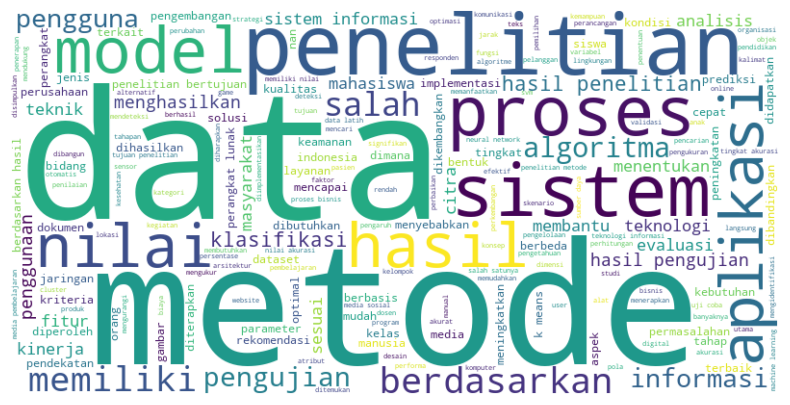

In [20]:
# tampilkan wordcloud hasil preprocessing
words = WordCloud(width=800, height=400, background_color='white', stopwords=stopwords_indo).generate(allText_forLDA)
plt.figure(figsize=(10, 5))
plt.imshow(words, interpolation='bilinear')
plt.axis('off')
plt.show()

## Simpan Hasil Preprocessing

In [21]:
df.to_csv('dataClean_withKey.csv', index=False)

## Bigram dan Trigram

In [22]:
# membuat model bigram dan trigram
bigram = gensim.models.Phrases(data_stopwords, min_count=5, threshold=5)
trigram = gensim.models.Phrases(bigram[data_stopwords], threshold=5)

bigram_mod = gensim.models.phrases.Phraser(bigram)
trigram_mod = gensim.models.phrases.Phraser(trigram)

# fungsi untuk membuat bigram dan trigram models

def make_bigrams(texts):
    return[bigram_mod[doc] for doc in texts]

def make_trigrams(texts):
    return[trigram_mod[bigram_mod[doc]] for doc in texts]

# Create data bigrams
data_bigram = make_bigrams(data_stopwords)

# Create data bigrams
data_trigram = make_trigrams(data_stopwords)

In [23]:
print(data_bigram[0])
print(data_trigram[0])
print(data_bigram[1])
print(data_trigram[1])
print(data_bigram[2])
print(data_trigram[2])
print(data_bigram[3])
print(data_trigram[3])
print(data_bigram[4])
print(data_trigram[4])
print(data_bigram[5])
print(data_trigram[5])

['penelitian_dikembangkan', 'metode_klasifikasi', 'berdasarkan', 'pengelompokan', 'k_means', 'lvq', 'metode', 'metode_klasifikasi', 'data', 'frekuensi', 'cenderung', 'pengujian', 'kelas', 'data', 'bermanfaat', 'langkah', 'pengelompokan', 'pengelompokkan', 'k_means', 'pengelompokan', 'mencapai', 'threshold', 'batasan', 'threshold', 'dicapai', 'cluster', 'kelas', 'berbeda', 'pembelajaran', 'lvq', 'akurasi', 'gabungan', 'k_means', 'lvq', 'k_means', 'murni', 'untukì£åâ', 'akurasi_tertinggi', 'k_means', 'lvq', 'didapatkan', '92', 'k_means', 'murni', '82', 'klasifikasi', 'pengelompokan', 'k_means', 'lvq']
['penelitian_dikembangkan', 'metode_klasifikasi', 'berdasarkan', 'pengelompokan', 'k_means_lvq', 'metode', 'metode_klasifikasi', 'data', 'frekuensi', 'cenderung', 'pengujian', 'kelas', 'data', 'bermanfaat', 'langkah', 'pengelompokan', 'pengelompokkan', 'k_means', 'pengelompokan', 'mencapai', 'threshold', 'batasan', 'threshold', 'dicapai', 'cluster', 'kelas', 'berbeda', 'pembelajaran', 'lvq'

# Pelabelan

Read Data Clean

In [24]:
df = pd.read_csv('dataClean_withKey.csv')

## Latent Dirichlet Allocation

In [25]:
# membuat dictionary dan corpus

dictionary = corpora.Dictionary(data_trigram)                                     # Membuat kamus dari daftar kata unik dalam dataset.
corpus = [dictionary.doc2bow(doc) for doc in data_trigram]                        # doc2bow(doc): Mengubah setiap dokumen menjadi representasi bag-of-words (BoW), di mana:
#                                                                                      - Setiap kata diberikan ID unik.
#                                                                                      - Representasi dokumen berupa daftar pasangan (ID_kata, frekuensi).

In [26]:
k_values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
perplexities = []
coherences = []

In [27]:
# uji coba coherence topik tertinggi
for k in k_values:
    lda_model = LdaModel(corpus, num_topics=k, id2word=dictionary, passes=10, random_state=42, alpha=0.1)

    # hitung perplexity
    perplexity = lda_model.log_perplexity(corpus)
    perplexities.append(perplexity)

    # hitung coherence score
    # coherence_model = CoherenceModel(model=lda_model, texts=df['Stemming'], dictionary=dictionary, coherence='c_v')
    coherence_model = CoherenceModel(model=lda_model, texts=data_trigram, dictionary=dictionary, coherence='c_v')
    coherence_score = coherence_model.get_coherence()
    coherences.append(coherence_score)
    print(f"Jumlah Topik: {k} | Perplexity: {perplexity:.4f} | Coherence Score: {coherence_score:4f}")

Jumlah Topik: 1 | Perplexity: -8.5688 | Coherence Score: 0.195379
Jumlah Topik: 2 | Perplexity: -8.5449 | Coherence Score: 0.226597
Jumlah Topik: 3 | Perplexity: -8.5451 | Coherence Score: 0.229031
Jumlah Topik: 4 | Perplexity: -8.5488 | Coherence Score: 0.218240
Jumlah Topik: 5 | Perplexity: -8.5559 | Coherence Score: 0.222579
Jumlah Topik: 6 | Perplexity: -8.5668 | Coherence Score: 0.220708
Jumlah Topik: 7 | Perplexity: -8.5744 | Coherence Score: 0.229732
Jumlah Topik: 8 | Perplexity: -8.5847 | Coherence Score: 0.224656
Jumlah Topik: 9 | Perplexity: -8.5904 | Coherence Score: 0.229575
Jumlah Topik: 10 | Perplexity: -8.6100 | Coherence Score: 0.220697


In [28]:
#  model untuk k= 7
lda_model = LdaModel(corpus, num_topics=7, id2word=dictionary, passes=10, random_state=42, alpha=0.1)

In [29]:
# Menentukan topik dominan untuk setiap dokumen

dominant_topics = []
for i, doc_bow in enumerate(corpus):
    # Mendapatkan distribusi topik untuk dokumen saat ini
    topic_distribution = lda_model.get_document_topics(doc_bow, minimum_probability=0.0)

    # Mengurutkan topik berdasarkan probabilitas dan ambil yang tertinggi
    # topic_distribution adalah list of (topic_id, probability)
    if topic_distribution: # Pastikan ada topik yang ditemukan
        dominant_topic_id = max(topic_distribution, key=lambda x: x[1])[0]
        dominant_topics.append(dominant_topic_id)
    else:
        dominant_topics.append(-1)

df['Topik'] = dominant_topics

In [30]:
df.head()

,Title,Abstract,abs_id,fitur,Casefolding,Tokenizing,Stopwords,Stemming,Clean_noStemming,Clean,Topik
0,Pengembangan Metode Klasifikasi Berdasarkan K-...,AbstrakPada penelitian ini dikembangkan metode...,pada penelitian ini dikembangkan metode klasif...,pada penelitian ini dikembangkan metode klasif...,pada penelitian ini dikembangkan metode klasif...,"['pada', 'penelitian', 'ini', 'dikembangkan', ...","['penelitian', 'dikembangkan', 'metode', 'klas...","['teliti', 'kembang', 'metode', 'klasifikasi',...",penelitian dikembangkan metode klasifikasi ber...,teliti kembang metode klasifikasi dasar kelomp...,5
1,Implementasi Teknik Watershed Dan Morfologi Pa...,AbstrakPenelitian di bidang segmentasi citra t...,penelitian di bidang segmentasi citra telah ba...,penelitian di bidang segmentasi citra telah ba...,penelitian di bidang segmentasi citra telah ba...,"['penelitian', 'di', 'bidang', 'segmentasi', '...","['penelitian', 'bidang', 'segmentasi', 'citra'...","['teliti', 'bidang', 'segmentasi', 'citra', 'b...",penelitian bidang segmentasi citra bidang citr...,teliti bidang segmentasi citra bidang citra sa...,6
2,Audit Dan Investigasi Sistem Keamanan Jaringan...,AbstrakPemanfaatan internet untuk bidang pendi...,pemanfaatan internet untuk bidang pendidikan t...,pemanfaatan internet untuk bidang pendidikan t...,pemanfaatan internet untuk bidang pendidikan t...,"['pemanfaatan', 'internet', 'untuk', 'bidang',...","['pemanfaatan', 'internet', 'bidang', 'pendidi...","['manfaat', 'internet', 'bidang', 'didik', 'ba...",pemanfaatan internet bidang pendidikan membant...,manfaat internet bidang didik bantu civitas ak...,2
3,Prediksi Cuaca Pada Data Time Series Menggunak...,AbstrakInformasi mengenai kondisi atmosfer yan...,informasi mengenai kondisi atmosfer yang cepat...,informasi mengenai kondisi atmosfer yang cepat...,informasi mengenai kondisi atmosfer yang cepat...,"['informasi', 'mengenai', 'kondisi', 'atmosfer...","['informasi', 'kondisi', 'atmosfer', 'cepat', ...","['informasi', 'kondisi', 'atmosfer', 'cepat', ...",informasi kondisi atmosfer cepat akurat terper...,informasi kondisi atmosfer cepat akurat perinc...,1
4,Implementasi Sensor Cahaya Sebagai Pengontrol ...,"Abstrak Dengan menggabungkan Sistem Kontrol, s...",dengan menggabungkan sistem kontrol sensor da...,dengan menggabungkan sistem kontrol sensor da...,dengan menggabungkan sistem kontrol sensor da...,"['dengan', 'menggabungkan', 'sistem', 'kontrol...","['menggabungkan', 'sistem', 'kontrol', 'sensor...","['gabung', 'sistem', 'kontrol', 'sensor', 'mot...",menggabungkan sistem kontrol sensor motor serv...,gabung sistem kontrol sensor motor servo harap...,6


In [31]:
words = 50

# Menampilkan kata-kata kunci untuk setiap topik
print(f"Kata-kata kunci untuk setiap topik (Top {words} kata):")

for idx, topic in lda_model.print_topics(num_words=words):
    print(f"Topik {idx}: \n{topic}")

Kata-kata kunci untuk setiap topik (Top 50 kata):
Topik 0: 
0.010*"aplikasi" + 0.007*"sistem" + 0.006*"metode" + 0.005*"data" + 0.005*"penelitian" + 0.005*"hasil" + 0.004*"nilai" + 0.004*"memiliki" + 0.004*"1" + 0.004*"salah" + 0.004*"pengujian" + 0.004*"proses" + 0.003*"pengguna" + 0.003*"berdasarkan" + 0.003*"model" + 0.003*"mahasiswa" + 0.003*"0" + 0.003*"5" + 0.003*"teknologi" + 0.003*"informasi" + 0.003*"hasil_pengujian" + 0.003*"masyarakat" + 0.002*"tingkat" + 0.002*"perangkat" + 0.002*"2" + 0.002*"menghasilkan" + 0.002*"evaluasi" + 0.002*"parameter" + 0.002*"dokumen" + 0.002*"fitur" + 0.002*"bentuk" + 0.002*"jarak" + 0.002*"3" + 0.002*"aspek" + 0.002*"citra" + 0.002*"penggunaan" + 0.002*"manusia" + 0.002*"membantu" + 0.002*"sistem_informasi" + 0.002*"perancangan" + 0.002*"nan" + 0.002*"berbasis" + 0.002*"akurasi" + 0.002*"kualitas" + 0.002*"kalimat" + 0.002*"kinerja" + 0.001*"layanan" + 0.001*"4" + 0.001*"klasifikasi" + 0.001*"kegiatan"
Topik 1: 
0.012*"data" + 0.008*"model" + 0

Simpan Data Terlabel

In [32]:
df.to_csv('dataTerlabel_withKey.csv')

## Visualisasi Grafik Uji Coba Jumlah Topik pada Model LDA
ujicoba k = 10

Coherence Score

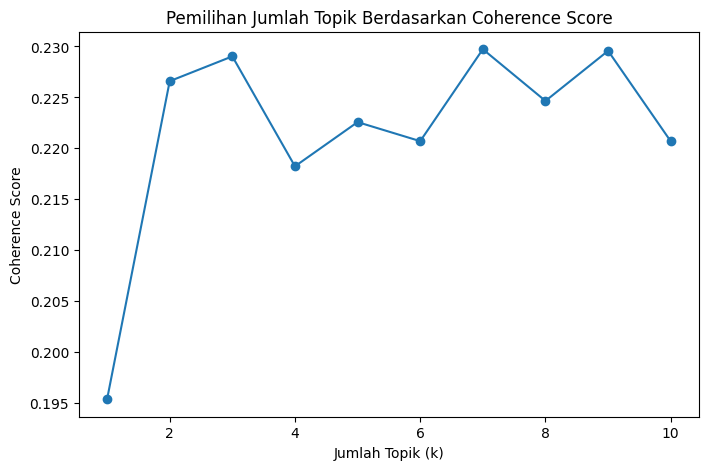

In [34]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, coherences, marker='o', linestyle='-')
plt.xlabel("Jumlah Topik (k)")
plt.ylabel("Coherence Score")
plt.title("Pemilihan Jumlah Topik Berdasarkan Coherence Score")
plt.show()

pyLDAvis

In [35]:
# Visualisasikan Topik
pyLDAvis.enable_notebook()

In [36]:
LDAvis_data_filepath = os.path.join('ldavis_prepared_'+str(k_values))       #menyimpan path file hasil visualisasi

In [37]:
# Mempersiapkan Data untuk Visualisasi
if 1 == 1:
    LDAvis_prepared = pyLDAvis.gensim.prepare(lda_model, corpus, dictionary)
    with open(LDAvis_data_filepath, 'wb') as f:
        pickle.dump(LDAvis_prepared, f)

with open(LDAvis_data_filepath, 'rb') as f:
    LDAvis_prepared = pickle.load(f)

LDAvis_prepared

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
4      0.026151  0.003337       1        1  23.572881
2      0.021435 -0.021455       2        1  14.149849
1     -0.071082  0.017772       3        1  14.123515
3      0.079351  0.010104       4        1  13.232445
0      0.062010  0.056954       5        1  12.587533
6     -0.094887  0.058834       6        1  12.058323
5     -0.022979 -0.125547       7        1  10.275453, topic_info=               Term         Freq        Total Category  logprob  loglift
44            citra   262.000000   262.000000  Default  30.0000  30.0000
413        aplikasi   504.000000   504.000000  Default  29.0000  29.0000
1197         barang    67.000000    67.000000  Default  28.0000  28.0000
10631        sampah    39.000000    39.000000  Default  27.0000  27.0000
22           metode  1108.000000  1108.000000  Default  26.0000  26.0000
...             ...          ...          ...      ...      ...      ...
638               1    27.874570   272.724960   Topic7  -6.1156  -0.0053
528    menghasilkan    26.213637   238.838791   Topic7  -6.1770   0.0659
908        pengguna    27.890796   314.651029   Topic7  -6.1150  -0.1478
452       teknologi    23.715806   211.837122   Topic7  -6.2771   0.0857
29        pengujian    24.629909   371.945136   Topic7  -6.2393  -0.4394

[577 rows x 6 columns], token_table=       Topic      Freq   Term
term                         
321        1  0.235941      0
321        2  0.128944      0
321        3  0.117970      0
321        4  0.115227      0
321        5  0.123457      0
...      ...       ...    ...
2400       1  0.794445  wi_fi
2400       2  0.148958  wi_fi
2400       6  0.049653  wi_fi
12246      3  0.953204    wpt
12727      1  0.886751   zona

[1203 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[5, 3, 2, 4, 1, 7, 6])

Wordcloud

# Penyeimbangan Data dengan SMOTE

In [39]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['Clean'])
Y = df['Topik']

0       5
1       6
2       2
3       1
4       6
       ..
1133    5
1134    3
1135    2
1136    4
1137    6
Name: Topik, Length: 1138, dtype: int64


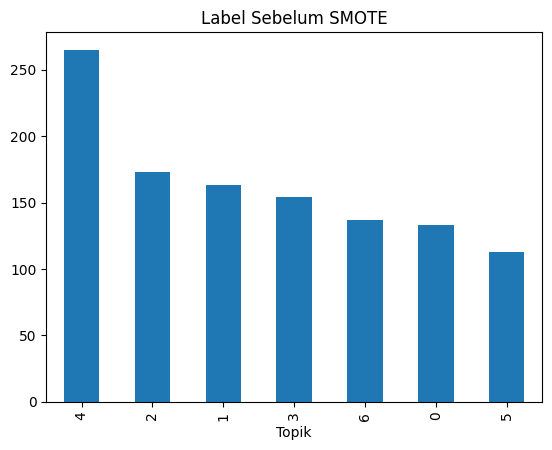

In [40]:
# menampilkan sebaran data
Y.value_counts().plot(kind='bar', title='Label Sebelum SMOTE')
print(Y)

In [41]:
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_resampled, Y_resampled = smote.fit_resample(X, Y)

# memperbarui data frame dengan fitur dan label yang sudah di oversampling
df_Smote = pd.DataFrame(X_resampled, columns=['Fitur'])
df_Smote['Label'] = Y_resampled

0       5
1       6
2       2
3       1
4       6
       ..
1850    6
1851    6
1852    6
1853    6
1854    6
Name: Topik, Length: 1855, dtype: int64


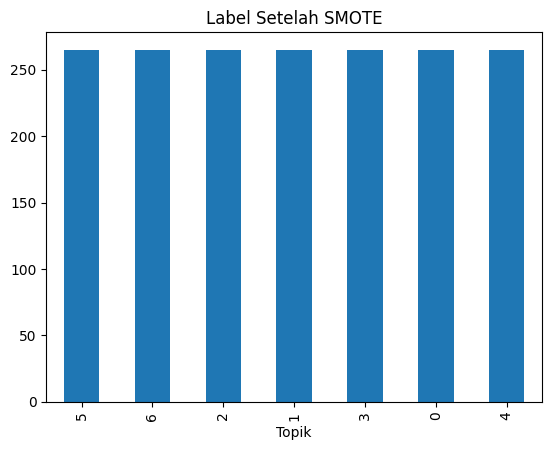

In [42]:
# menampilkan sebaran data setelah SMOTE
Y_resampled.value_counts().plot(kind='bar', title='Label Setelah SMOTE')
print(Y_resampled)

In [43]:
# simpan hasil smote
df_Smote.to_csv('dataClean_SMOTE.csv', index=False)

# Spliting Data

In [44]:
x_train, x_test, y_train, y_test = model_selection.train_test_split(X_resampled, Y_resampled, test_size=0.3)

In [45]:
x_train,y_train

(<1298x11108 sparse matrix of type '<class 'numpy.float64'>'
 	with 121838 stored elements in Compressed Sparse Row format>,
 1080    3
 218     1
 793     4
 1043    2
 1644    5
        ..
 587     3
 831     3
 1375    2
 1207    0
 954     4
 Name: Topik, Length: 1298, dtype: int64)

# Pelatihan Klasifikasi

In [46]:
SVM = svm.SVC(kernel='rbf', C=100)
SVM.fit(x_train, y_train)

SVC(C=100)

In [47]:
y_pred = SVM.predict(x_test)

#### Hasil Akurasi tanpa cross validation

In [48]:
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[61  2  0  1 12  1  0]
 [ 2 58  0  0 16  0  2]
 [ 1  2 56  1 19  0  0]
 [ 0  2  4 57 20  2  0]
 [ 1  6 10  0 61  0  3]
 [ 0  1  1  0  8 76  1]
 [ 1  2  1  0 12  0 54]]
              precision    recall  f1-score   support

           0       0.92      0.79      0.85        77
           1       0.79      0.74      0.77        78
           2       0.78      0.71      0.74        79
           3       0.97      0.67      0.79        85
           4       0.41      0.75      0.53        81
           5       0.96      0.87      0.92        87
           6       0.90      0.77      0.83        70

    accuracy                           0.76       557
   macro avg       0.82      0.76      0.78       557
weighted avg       0.82      0.76      0.78       557



# Simpan Model

In [49]:
joblib.dump(vectorizer, 'TFIDFvectorizer.pkl')
joblib.dump(lda_model, 'lda_model_withKey.pkl')
joblib.dump(SVM, 'svm_model.pkl')

['svm_model.pkl']

# Deployment

Load Pipeline

In [50]:
Vectorizer = joblib.load('TFIDFvectorizer.pkl')
svm_model = joblib.load('svm_model.pkl')

In [ ]:
def klasifikasi(text):
  tfidf_vektor = Vectorizer.transform([text])
  pred = svm_model.predict(tfidf_vektor)
  if pred == 0:
    category = "Aplikasi dan Evaluasi Sistem"
  elif pred == 1:
    category = "Model dan Klasifikasi Data"
  elif pred == 2:
    category = "Sistem dan Jaringan"
  elif pred == 3:
    category = "Sistem Informasi dan Evaluasi Website"
  elif pred == 4:
    category = "Analisis Data dan Pembelajaran"
  elif pred == 5:
    category = "Pembelajaran dan Lingkungan"
  elif pred == 6:
    category = "Citra dan Identifikasi"
  # elif pred == 7:
  #   category = "Topik 8"
  # elif pred == 8:
  #   category = "Topik 9"
  # elif pred == 9:
  #   category = "Topik 10"
  else:
    category = "Error"
  return category

In [52]:
masukkan_kalimat = str(input("Masukkan Review :"))
masukkan_kalimat = casefolding(masukkan_kalimat)
masukkan_kalimat = word_tokenize_wrapper(masukkan_kalimat)
masukkan_kalimat = stopwordText(masukkan_kalimat)
masukkan_kalimat = stemmingText(masukkan_kalimat)
masukkan_kalimat = " ".join(masukkan_kalimat)

print(masukkan_kalimat)
print("Hasil Klasifikasi :",klasifikasi(masukkan_kalimat))

kembang teknologi era bidang multimedia musik dar hibur senang tumbuh musik online tingkat musik klasifikasi dasar genre genre musik kelompok musik mirip teliti sistem bangun naive bayes classifier guna prediksi lagu dasar lirik lagu teliti dataset bagi genre blues electronic r  b christian hip hop rap rock country jazz ska dance pop soul oleh akurasi konten musik 45 konteks guna akurasi 60 kunci genre naive bayes konten musik konteks guna
Hasil Klasifikasi : Topik 5
